<a href="https://colab.research.google.com/github/premkumar-12/Computer-Vision/blob/main/Pose-Estimation/pose_estimation_mediapipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 3d-man.gif to 3d-man.gif


In [2]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 0.10.32
    Uninstalling mediapipe-0.10.32:
      Successfully uninstalled mediapipe-0.10.32
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires proto

In [1]:
import os
print(os.listdir())

['.config', '3d-man.gif', 'sample_data']


In [2]:
import mediapipe as mp
print("MediaPipe version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe version: 0.10.14
Has solutions: True


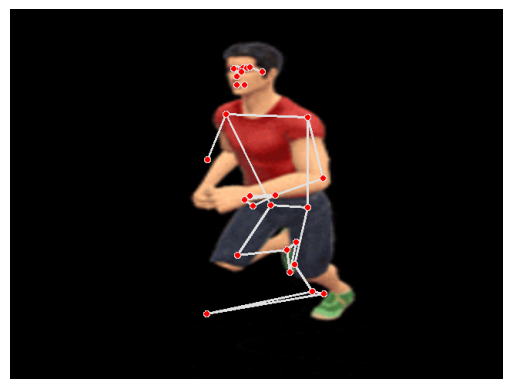

In [3]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Initialize MediaPipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5,
                    min_tracking_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils

def estimate_pose_from_video(video_path, width=640, height=480):
    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Resize frame
        frame_resized = cv2.resize(frame, (width, height))

        # Convert to RGB
        frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)

        # Pose detection
        results = pose.process(frame_rgb)

        # Draw skeleton
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                frame_resized,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS
            )

        # Display in Colab
        plt.imshow(cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        display(plt.gcf())
        clear_output(wait=True)

    cap.release()

# ⚠️ VERY IMPORTANT — change filename here
video_path = "3d-man.gif"
estimate_pose_from_video(video_path)